**Import Libraries**

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torch.utils.data import TensorDataset
from torch.utils.data import Dataset
from torch.nn.utils.rnn import pad_sequence
import matplotlib.pyplot as plt
from tqdm.auto import trange
import numpy as np
import os
import random


In [2]:
#Check if CUDA is being used

import subprocess, sys, torch, os, platform
print("# PyTorch", torch.__version__)
print("# torch.version.cuda", torch.version.cuda)
print("# CUDA available:", torch.cuda.is_available())
print("# device_count:", torch.cuda.device_count())
print("# nvidia-smi:")
subprocess.run(["nvidia-smi"])

# PyTorch 2.3.1+cu121
# torch.version.cuda 12.1
# CUDA available: True
# device_count: 1
# nvidia-smi:


CompletedProcess(args=['nvidia-smi'], returncode=0)

**Parameters for data preprocessing**

In [3]:
# Number of file to pick in both training and development set
# num_files_to_pick = 10000                                                             

### Filepaths LFCC ###
# Training
data_dir = 'D:\\Felipe\\Team Lab\\teamlab-phonetics\\feature_extraction\\stft_segment_outputs\\stft_training_set'

# Development/Validation
dev_data_dir = 'D:\\Felipe\\Team Lab\\teamlab-phonetics\\feature_extraction\\stft_segment_outputs\\stft_dev_set'


**Preprocessing of training data** 

In [4]:
# Set the number of files to pick and the random seed
#random_seed = 42

# List all .pt files in the directory
all_files = [f for f in os.listdir(data_dir) if f.endswith('.pt')]

# Set the random seed for reproducibility
#random.seed(random_seed)

# Randomly select the specified number of files
# selected_files = random.sample(all_files, num_files_to_pick)

# Inspect a single .pt file before loading into classes
inspect_file = os.path.join(data_dir, all_files[0])  # Select the first file from the random selection

# Inspect the data from the .pt file
inspect_data = torch.load(inspect_file)
print("Example of the .pt file",inspect_data[0])

# Initialize a list to store the features and labels
features_list = []
labels_list = []

# Load the features and labels for the selected .pt files
for file_name in all_files:
    file_path = os.path.join(data_dir, file_name)
    feature, label = torch.load(file_path)
    features_list.append(feature)  # Append the tensors
    labels_list.append(label) # Append the labels

# Concatenate all the data into a single tensor
features = torch.stack(features_list)
print("Example of the features",features[1])
labels = torch.tensor(labels_list)
print("Example of the labels",labels)

# Debugging: Check the shapes of features and labels
print("Features shape:", features.shape)
print("Labels shape:", labels.shape)

# Create a TensorDataset and DataLoader
dataset = TensorDataset(features, labels)
dataLoader = DataLoader(dataset, batch_size=64, shuffle=True)
print("The training dataset has been successfully loaded into DataLoader.")

Example of the .pt file tensor([[1.4188e-02, 6.2743e-03, 1.2903e-03,  ..., 2.8582e-03, 6.7049e-01,
         1.3368e+00],
        [1.4236e-02, 6.8283e-03, 4.3430e-04,  ..., 3.3879e-03, 6.7229e-01,
         1.3419e+00],
        [1.5080e-02, 6.7492e-03, 1.0667e-03,  ..., 3.1254e-03, 6.8002e-01,
         1.3567e+00],
        ...,
        [4.4041e-04, 2.0487e-04, 1.3002e-04,  ..., 5.2026e-04, 1.8338e-02,
         3.6456e-02],
        [2.9080e-04, 5.2668e-04, 5.7477e-04,  ..., 1.0172e-03, 1.7808e-02,
         3.6584e-02],
        [6.4986e-05, 4.9668e-04, 8.5588e-04,  ..., 1.2491e-03, 1.9211e-02,
         3.6782e-02]])
Example of the features tensor([[4.7806e-02, 2.8068e-02, 1.5607e-04,  ..., 1.6649e-04, 2.1217e-01,
         2.9756e-01],
        [4.8554e-02, 2.8411e-02, 2.4167e-04,  ..., 8.7382e-04, 2.2251e-01,
         3.2261e-01],
        [5.0676e-02, 2.9244e-02, 1.2388e-04,  ..., 2.0188e-03, 2.5136e-01,
         3.9264e-01],
        ...,
        [3.2983e-03, 6.7003e-03, 4.7199e-03,  ..., 9

**Dataset inspection**

In [5]:
# Inspect the range of labels in the dataset
#print("Minimum label value:", labels.min().item())
#print("Maximum label value:", labels.max().item())
#print("Unique label values:", torch.unique(labels))

# Inspect the first sample in the batch
print("First sample shape:", features[0].shape)
print("First sample values:\n", features[0])


# Inspect the concatenated tensor
#print("Data Tensor Shape:", data_tensor.shape)
#print("Data Tensor Data Type:", data_tensor.dtype)
#print("Sample Data Tensor Values:\n", data_tensor[:5])  # Print the first 5 rows

# Inspect features and labels
#print("Features Shape:", features.shape)
#print("Labels Shape:", labels.shape)
#print("Sample Features:\n", features[:5])  # Print the first 5 rows of features
print("Sample Labels:\n", labels[:100])  # Print the first 5 labels

First sample shape: torch.Size([1025, 126])
First sample values:
 tensor([[1.4188e-02, 6.2743e-03, 1.2903e-03,  ..., 2.8582e-03, 6.7049e-01,
         1.3368e+00],
        [1.4236e-02, 6.8283e-03, 4.3430e-04,  ..., 3.3879e-03, 6.7229e-01,
         1.3419e+00],
        [1.5080e-02, 6.7492e-03, 1.0667e-03,  ..., 3.1254e-03, 6.8002e-01,
         1.3567e+00],
        ...,
        [4.4041e-04, 2.0487e-04, 1.3002e-04,  ..., 5.2026e-04, 1.8338e-02,
         3.6456e-02],
        [2.9080e-04, 5.2668e-04, 5.7477e-04,  ..., 1.0172e-03, 1.7808e-02,
         3.6584e-02],
        [6.4986e-05, 4.9668e-04, 8.5588e-04,  ..., 1.2491e-03, 1.9211e-02,
         3.6782e-02]])
Sample Labels:
 tensor([0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0,
        0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
        0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
  

**Testing the Data Loader**

In [6]:
print(len(dataset[0][0]))
print(features.shape)

for batch in dataLoader:
    features, labels = batch
    print("Batch features shape:", features.shape)
    break

1025
torch.Size([25380, 1025, 126])
Batch features shape: torch.Size([64, 1025, 126])


**Preprocessing and loading the Development/Validation Set**

In [7]:
# Set the number of files to pick and the random seed
#random_seed = 42

# List all .pt files in the directory
all_files = [f for f in os.listdir(dev_data_dir) if f.endswith('.pt')]

# Set the random seed for reproducibility
#random.seed(random_seed)

# Randomly select the specified number of files
# selected_files = random.sample(all_files, num_files_to_pick)

# Inspect a single .pt file before loading into classes
inspect_file = os.path.join(dev_data_dir, all_files[0])  # Select the first file from the random selection

# Inspect the data from the .pt file
inspect_data = torch.load(inspect_file)
print("Example of the .pt file",inspect_data[0])

# Initialize a list to store the features and labels
dev_features_list = []
dev_labels_list = []

# Load the features and labels for the selected .pt files
for file_name in all_files:
    file_path = os.path.join(dev_data_dir, file_name)
    dev_feature, dev_label = torch.load(file_path)
    dev_features_list.append(dev_feature)  # Append the tensors
    dev_labels_list.append(dev_label) # Append the labels

# Concatenate all the data into a single tensor
dev_features = torch.stack(dev_features_list)
print("Example of the features",dev_features[1])
dev_labels = torch.tensor(dev_labels_list)
print("Example of the labels",dev_labels)

# Debugging: Check the shapes of features and labels
print("Features shape:", dev_features.shape)
print("Labels shape:", dev_labels.shape)

# Create a TensorDataset and DataLoader
dev_dataset = TensorDataset(dev_features, dev_labels)
dev_dataLoader = DataLoader(dev_dataset, batch_size=64, shuffle=False)
print("The development dataset has been successfully loaded into DataLoader.")

Example of the .pt file tensor([[0.0028, 0.0082, 0.0031,  ..., 0.0009, 0.0171, 0.1211],
        [0.0145, 0.0108, 0.0023,  ..., 0.0008, 0.0468, 0.1536],
        [0.0295, 0.0177, 0.0032,  ..., 0.0003, 0.0922, 0.2178],
        ...,
        [0.0028, 0.0010, 0.0010,  ..., 0.0016, 0.0221, 0.0454],
        [0.0026, 0.0016, 0.0017,  ..., 0.0008, 0.0226, 0.0453],
        [0.0030, 0.0016, 0.0012,  ..., 0.0003, 0.0230, 0.0454]])
Example of the features tensor([[1.3280e-02, 6.5576e-03, 7.4601e-04,  ..., 2.3259e-03, 4.5535e-01,
         9.6070e-01],
        [1.3487e-02, 7.0941e-03, 1.7459e-04,  ..., 2.7390e-03, 4.5751e-01,
         9.6553e-01],
        [1.4015e-02, 6.8022e-03, 3.6806e-04,  ..., 3.9689e-03, 4.6491e-01,
         9.7904e-01],
        ...,
        [5.1039e-04, 2.6906e-03, 3.3772e-03,  ..., 3.1965e-01, 2.6352e-01,
         1.6747e-01],
        [5.5618e-04, 2.8872e-03, 3.1404e-03,  ..., 1.2971e-01, 5.6825e-02,
         9.2420e-02],
        [1.0293e-03, 3.1387e-03, 1.8651e-03,  ..., 7.933

**Testing the Processed Dataloaders and Label Distribution**

In [8]:
print("Training features shape",features.shape,"[1] batch size | [2] Coefficients | [3] Timeframes")
print("Training labels shape",labels.shape)
print("Development features shape:", dev_features.shape,"[1] batch size | [2] Coefficients | [3] Timeframes")
print("Development labels shape:", dev_labels.shape)

print("Training label distribution:", torch.bincount(labels))
print("Validation label distribution:", torch.bincount(dev_labels))

Training features shape torch.Size([64, 1025, 126]) [1] batch size | [2] Coefficients | [3] Timeframes
Training labels shape torch.Size([64])
Development features shape: torch.Size([24844, 1025, 126]) [1] batch size | [2] Coefficients | [3] Timeframes
Development labels shape: torch.Size([24844])
Training label distribution: tensor([62,  2])
Validation label distribution: tensor([22296,  2548])


**Hyperparemeters**

In [16]:
hidden_dim = 128  # Number of neurons in the hidden layer
dropout_prob = 0.5  # Dropout probability

**Neural Network Model**

In [17]:
class SpoofDetectionModel(nn.Module):
    def __init__(self, hidden_dim, dropout_prob):
        super(SpoofDetectionModel, self).__init__()
        
        # 1D Convolutional layers
        self.conv1 = nn.Conv1d(in_channels=1025, out_channels=32, kernel_size=3, stride=1, padding=1) # in channels = LFCC coefficients
        self.conv2 = nn.Conv1d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1)
        self.pool = nn.MaxPool1d(kernel_size=2, stride=2, padding=0)
        
        # Dropout layer
        self.dropout = nn.Dropout(dropout_prob)
        
        # Fully connected layers
        self.fc1 = None  # Placeholder, will be initialized dynamically
        self.fc3 = nn.Linear(hidden_dim, 1)  # Single output neuron for binary classification
        
        # Initialize weights
        self.init_weights()
        
    def init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv1d) or isinstance(m, nn.Linear):
                torch.nn.init.kaiming_uniform_(m.weight, mode='fan_in', nonlinearity='relu')
                if m.bias is not None:
                    torch.nn.init.zeros_(m.bias)
        
    def forward(self, x):
        # Input x is already (batch_size, num_channels, sequence_length) for MFCC: [batch, 40, 126]
        
        # Convolutional layers
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = self.dropout(x)  # Apply dropout after convolutional layers
        
        # Flatten the output for the fully connected layer
        x = x.view(x.size(0), -1)
        
        # Dynamically initialize fc1 if not already done
        if self.fc1 is None:
            self.fc1 = nn.Linear(x.size(1), hidden_dim).to(x.device)
        
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)  # Apply dropout after the first fully connected layer
        x = self.fc3(x)  # Output layer: Sigmoid for binary classification / previous line (before BCEwithLogits): x = torch.sigmoid(self.fc3(x))
        
        return x

**Initializing the model**

In [18]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = SpoofDetectionModel(hidden_dim, dropout_prob).to(device)

print(device)

cuda


**Calculate the weights proportion for weighted loss**

In [19]:
'''Formula: weight_for_class_i = total_samples / (num_samples_in_class_i * num_classes)

print("Training label distribution:", torch.bincount(labels))
print("Validation label distribution:", torch.bincount(dev_labels))

Training label distribution: tensor([26,  6])
Validation label distribution: tensor([8949, 1051])
'''

# Proportion of samples of the development set
counts = torch.bincount(dev_labels) # tensor with [SPOOF, BONAFIDE]
proportions = counts / len(dev_labels) * 100
prop_spoof = float(proportions[0])
prop_bonafide = float(proportions[1])
print("Proportion of the Development Set:\n",f"Spoof: {prop_spoof:.2f}% | Bonafide: {prop_bonafide:.2f}%")


weight_for_class_0 = (len(dev_labels) / (torch.bincount(dev_labels)[0] * 2))
print("Weight of class 0 (spoof):",weight_for_class_0)

weight_for_class_1 = (len(dev_labels) / (torch.bincount(dev_labels)[1] * 2))
print("Weight of class 1 (bonafide):",weight_for_class_1)

weighted_loss_pos = torch.tensor(weight_for_class_1)
print("Weight tensor to be passed to the Loss Function",weighted_loss_pos)

Proportion of the Development Set:
 Spoof: 89.74% | Bonafide: 10.26%
Weight of class 0 (spoof): tensor(0.5571)
Weight of class 1 (bonafide): tensor(4.8752)
Weight tensor to be passed to the Loss Function tensor(4.8752)


C:\Users\fnobrega\AppData\Local\Temp\ipykernel_20668\4247703482.py:24: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  weighted_loss_pos = torch.tensor(weight_for_class_1)


**Loss function and Optimizer**

In [20]:

criterion = nn.BCEWithLogitsLoss(pos_weight=weighted_loss_pos)  # Binary cross-entropy loss
optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)  # Learning rate + weight decay

**Metric Initialization / Learning Scheduler / Early stopping**

In [21]:
import matplotlib.pyplot as plt

# Initialize lists to store metrics
losses_train = [] # Stores the average training loss for each epoch.
losses_val = [] # Stores the average validation loss for each epoch.
accuracies_train = [] # Stores the training accuracy for each epoch.
accuracies_val = [] # Stores the validation accuracy for each epoch.
eers_val = []

### Learning rate scheduler to reduce the learning rate during training
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3)

# Initialize variables for early stopping
best_eer = float('inf')  # Track the best validation loss
patience = 5  # Number of epochs to wait for improvement
counter = 0   # Counter for early stopping



**Training Loop**

In [22]:
import numpy as np
from sklearn.metrics import roc_curve, f1_score
from scipy.special import expit  # sigmoid function
# Training loop
num_epochs = 100

def calculate_eer(labels, scores):
    fpr, tpr, thresholds = roc_curve(labels, scores, pos_label=1)
    fnr = 1 - tpr
    eer_idx = np.nanargmin(np.abs(fnr - fpr))
    eer = (fpr[eer_idx] + fnr[eer_idx]) / 2
    return eer * 100, thresholds[eer_idx]

for epoch in range(num_epochs):
    model.train() # Set model to training mode
    epoch_loss_train = 0.0
    correct_train = 0
    total_train = 0

    # Training phase
    for batch_idx, (features, labels) in enumerate(dataLoader):
        features, labels = features.to(device), labels.to(device) #for LFCC -> old code, possibly for wav2vec: features, labels = features.unsqueeze(1).to(device), labels.to(device)
        
        # Forward pass
        outputs = model(features)
        loss = criterion(outputs, labels.float().unsqueeze(1))  # Reshape labels to [batch_size, 1]

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Accumulate training loss and accuracy
        epoch_loss_train += loss.item()
        predicted = (outputs > 0).float()
        total_train += labels.size(0)
        correct_train += (predicted.squeeze() == labels).sum().item()

    # Compute average training loss and accuracy for the epoch
    avg_loss_train = epoch_loss_train / len(dataLoader)
    accuracy_train = 100 * correct_train / total_train
    losses_train.append(avg_loss_train)
    accuracies_train.append(accuracy_train)

    # -------- VALIDATION PHASE + EER --------
    model.eval()
    epoch_loss_val = 0.0
    correct_val = 0
    total_val = 0
    all_scores = []
    all_labels = []

    with torch.no_grad():
        for features, labels in dev_dataLoader:
            features, labels = features.to(device), labels.to(device)
            outputs = model(features)
            loss = criterion(outputs, labels.float().unsqueeze(1)) # Reshape labels to [batch_size, 1]

            # Accumulate validation loss and accuracy
            epoch_loss_val += loss.item()
            predicted = (outputs > 0).float()
            correct_val += (predicted.squeeze() == labels).sum().item()
            total_val += labels.size(0)

            all_scores.extend(outputs.cpu().numpy().flatten())
            all_labels.extend(labels.cpu().numpy())

    # Compute average validation loss and accuracy for the epoch
    avg_loss_val = epoch_loss_val / len(dev_dataLoader)
    accuracy_val = 100 * correct_val / total_val
    losses_val.append(avg_loss_val)
    accuracies_val.append(accuracy_val)

    # --- Calculate EER on validation set ---
    eer_val, threshold_val = calculate_eer(np.array(all_labels), np.array(all_scores))
    eers_val.append(eer_val)

    # Print metrics
    print(f"Epoch [{epoch+1}/{num_epochs}] | "
          f"Train Loss: {avg_loss_train:.4f}, Acc: {accuracy_train:.2f}% | "
          f"Val Loss: {avg_loss_val:.4f}, Acc: {accuracy_val:.2f}% | "
          f"Val EER: {eer_val:.2f}%"
          f"Val Threshold: {threshold_val:.2f}%")

    # Learning rate scheduling
    scheduler.step(avg_loss_val)


    # --- Early Stopping Based on Validation EER ---
    if eer_val < best_eer:
        best_eer = eer_val
        best_threshold = threshold_val  # Save the threshold for best EER
        torch.save(model.state_dict(), 'saved_models/stft_v5_best_model.pth')
    # Save the threshold to a file
        with open('saved_models/stft_v5_best_threshold.txt', 'w') as f:
            f.write(str(best_threshold))
            f.write(str(best_eer))
        counter = 0
    else:
        counter += 1
        print(f"EER not improved. Patience counter: {counter}/{patience}")
        if counter >= patience and epoch >= 10:
            print("Early stopping triggered (EER did not improve).")
            break

Epoch [1/100] | Train Loss: 1.3780, Acc: 53.99% | Val Loss: 0.9049, Acc: 72.95% | Val EER: 41.18%Val Threshold: -0.11%
Epoch [2/100] | Train Loss: 0.9351, Acc: 67.61% | Val Loss: 0.8522, Acc: 86.62% | Val EER: 37.71%Val Threshold: -0.37%
Epoch [3/100] | Train Loss: 0.8907, Acc: 76.35% | Val Loss: 0.8431, Acc: 89.00% | Val EER: 34.39%Val Threshold: -0.43%
Epoch [4/100] | Train Loss: 0.8550, Acc: 81.15% | Val Loss: 0.8354, Acc: 89.35% | Val EER: 32.73%Val Threshold: -0.43%
Epoch [5/100] | Train Loss: 0.8306, Acc: 83.56% | Val Loss: 0.8148, Acc: 89.67% | Val EER: 30.34%Val Threshold: -0.55%
Epoch [6/100] | Train Loss: 0.8081, Acc: 85.54% | Val Loss: 0.7968, Acc: 89.73% | Val EER: 29.22%Val Threshold: -0.64%
Epoch [7/100] | Train Loss: 0.7799, Acc: 86.47% | Val Loss: 0.7846, Acc: 89.74% | Val EER: 27.66%Val Threshold: -0.59%
Epoch [8/100] | Train Loss: 0.7531, Acc: 87.53% | Val Loss: 0.7672, Acc: 89.75% | Val EER: 26.48%Val Threshold: -0.64%
Epoch [9/100] | Train Loss: 0.7220, Acc: 88.45% 

In [16]:
print(threshold_val)

-2.0839856


**Plotting the results**

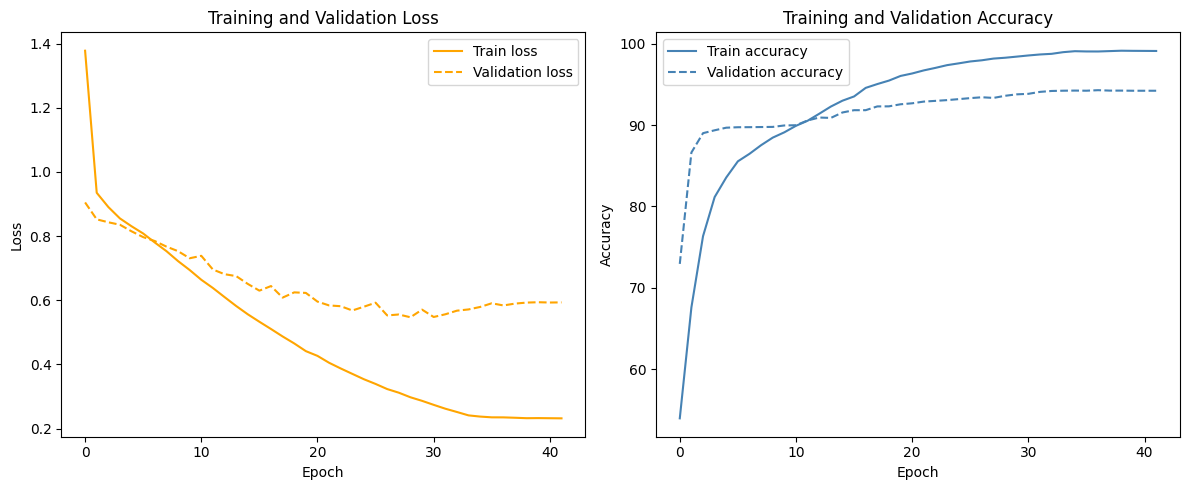

In [23]:
import matplotlib.pyplot as plt

# Plot training and validation loss
plt.figure(figsize=(12, 5))

# Loss plot
plt.subplot(1, 2, 1)
plt.plot(losses_train, color="orange", linestyle="-", label="Train loss")
plt.plot(losses_val, color="orange", linestyle="--", label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()

# Accuracy plot
plt.subplot(1, 2, 2)
plt.plot(accuracies_train, color="steelblue", linestyle="-", label="Train accuracy")
plt.plot(accuracies_val, color="steelblue", linestyle="--", label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

**Saving the model** (Actually don't do it, use the version saved in early stopping)

In [ ]:
# Save weights only
#torch.save(model.state_dict(), 'lfcc_with_delta_v3_updated_model_deepfake_audio_detection_model.pth')

# Save the full model (architecture + weights)
#torch.save(model, 'lfcc_with_delta_v2_updated_model_deepfake_audio_detection_model_full.pt')

**Prepare Evaluation Dataset**

In [24]:
# Evaluation
eval_data_dir = 'D:\\Felipe\\Team Lab\\teamlab-phonetics\\feature_extraction\\stft_segment_outputs\\stft_eval_set'

from torch.utils.data import Dataset, DataLoader

class EvalAudioDataset(Dataset):
    def __init__(self, data_dir):
        self.file_list = [f for f in os.listdir(data_dir) if f.endswith('.pt')]
        self.data_dir = data_dir

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        file_path = os.path.join(self.data_dir, self.file_list[idx])
        feature, label = torch.load(file_path)
        return feature, label

# Inspect a single .pt file before loading into classes
all_files = [f for f in os.listdir(eval_data_dir) if f.endswith('.pt')]
inspect_file = os.path.join(eval_data_dir, all_files[0])
inspect_data = torch.load(inspect_file)
print("Example of the .pt file", inspect_data[0])

# Create the Dataset and DataLoader
eval_dataset = EvalAudioDataset(eval_data_dir)
eval_dataLoader = DataLoader(eval_dataset, batch_size=32, shuffle=False)
print("The evaluation dataset has been successfully loaded into DataLoader.")

Example of the .pt file tensor([[4.7389e-02, 2.0258e-02, 6.3379e-03,  ..., 1.6565e-03, 7.3179e-01,
         1.3399e+00],
        [4.8367e-02, 2.4457e-02, 5.9164e-03,  ..., 1.8640e-03, 7.3369e-01,
         1.3379e+00],
        [4.9295e-02, 2.9524e-02, 7.3539e-03,  ..., 3.8764e-03, 7.4379e-01,
         1.3821e+00],
        ...,
        [3.8142e-03, 2.3867e-03, 2.7212e-03,  ..., 2.7038e-03, 1.0920e-02,
         1.4034e-02],
        [3.4697e-03, 4.0151e-03, 5.8978e-03,  ..., 3.9715e-03, 6.3027e-03,
         8.7520e-03],
        [3.0438e-03, 4.0966e-04, 8.1186e-03,  ..., 3.8899e-04, 2.1928e-03,
         4.2624e-03]])
The evaluation dataset has been successfully loaded into DataLoader.



Evaluation Set:
Loss: 0.8250 | Accuracy: 71.55%
EER: 29.27% | Logit Threshold: -0.0679 | Prob Threshold: 0.4830
F1 Score: 0.3329
Precision: 0.2176
Recall: 0.7073
Predictions: [1]: 23902 | [0]: 47335


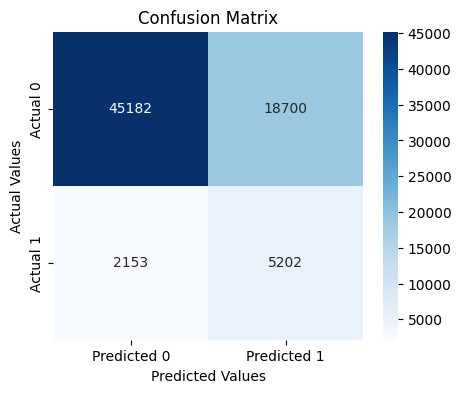

In [25]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns

def evaluate_on_eval_set(model, eval_dataLoader):
    model.eval()
    all_scores = []
    all_labels = []
    total = 0
    correct = 0
    total_loss = 0.0

    with torch.no_grad():
        for features, labels in eval_dataLoader:
            features, labels = features.to(device), labels.to(device)
            outputs = model(features)
            loss = criterion(outputs, labels.float().unsqueeze(1))

            total_loss += loss.item()
            predicted = (outputs > 0).float()
            correct += (predicted.squeeze() == labels).sum().item()
            total += labels.size(0)

            all_scores.extend(outputs.cpu().numpy().flatten())
            all_labels.extend(labels.cpu().numpy())

    # Convert to NumPy arrays
    all_labels = np.array(all_labels)
    all_scores = np.array(all_scores)
    
    # Metrics
    avg_loss = total_loss / len(eval_dataLoader)
    accuracy = 100 * correct / total
    eer, threshold = calculate_eer(all_labels, all_scores)
    prob_threshold = expit(threshold)
    preds = (all_scores >= threshold).astype(int)
    
    # Calculate precision and recall
    precision = precision_score(all_labels, preds)
    recall = recall_score(all_labels, preds)
    f1 = f1_score(all_labels, preds)

    # Print results with precision and recall
    print(f"\nEvaluation Set:")
    print(f"Loss: {avg_loss:.4f} | Accuracy: {accuracy:.2f}%")
    print(f"EER: {eer:.2f}% | Logit Threshold: {threshold:.4f} | Prob Threshold: {prob_threshold:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"Predictions: [1]: {np.count_nonzero(preds == 1)} | [0]: {np.count_nonzero(preds == 0)}")

    # Confusion Matrix
    cm = confusion_matrix(all_labels, preds)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Predicted 0', 'Predicted 1'],
                yticklabels=['Actual 0', 'Actual 1'])
    plt.xlabel('Predicted Values')
    plt.ylabel('Actual Values')
    plt.title('Confusion Matrix')
    plt.show()

evaluate_on_eval_set(model, eval_dataLoader)